We chose 20 Chinese A-share companies for this experiment. Their shares are listed in Shanghai or Shenzhen. All 20 have daily price records from early 2016 to 9 October 2026, although some have gaps. The company table shows what each business does, and the data table shows how much history we have.

We tested Ridge, Elastic Net, KNN, SVR, Random Forest, Extra Trees, XGBoost, MLP, LSTM and CNN. We also added Prophet from our earlier trend experiment. The aim was to predict the next month's returns for Value, Profitability and Momentum, then use those predictions to decide how much to put into each factor.

We used the same test dates, costs and portfolio rules for every model. For comparison, we split money equally between the three factors and also built a portfolio with 5% in each of the 20 stocks. We tried monthly and four-week rebalancing, long-short portfolios and sector-neutral portfolios.

All eleven models completed the test. We ended up with 58 portfolio comparisons over 21 monthly holding periods. Each part below explains what we did and what we found.

In [1]:
from pathlib import Path
import contextlib
import io
import logging
import warnings
import torch
from torch import nn
from prophet import Prophet
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

In [2]:
pd.options.display.float_format = '{:,.3f}'.format
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False})

shell = get_ipython()
if shell is not None:
    with contextlib.redirect_stdout(io.StringIO()):
        shell.run_line_magic('xmode', 'Minimal')

In [3]:
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'inputs/china_stock_20').is_dir())
INPUTS = ROOT / 'inputs/china_stock_20'
RESULTS = ROOT / 'results/china_stock_monthly'
RESULTS.mkdir(parents=True, exist_ok=True)
companies = pd.read_csv(INPUTS / 'stocks.csv').set_index('ticker')
STOCKS = companies.index.tolist()
if len(STOCKS) != 20 or len(set(STOCKS)) != 20:
    raise ValueError('This experiment requires exactly 20 different A-share companies.')
if not companies.index.str.fullmatch(r'(?:6[0-9]{5}\.SH|[03][0-9]{5}\.SZ)').all():
    raise ValueError('Use Shanghai or Shenzhen A-share stock codes.')

company_table = companies.reset_index()[['name', 'ticker', 'business']].rename(columns={'name': 'Company', 'ticker': 'A-share code', 'business': 'Main business'})
company_table.index = range(1, len(company_table) + 1)
company_table.index.name = '#'
print(f'{len(companies)} companies')
display(company_table)

20 companies


,Company,A-share code,Main business
#,,,
1,NAURA Technology,002371.SZ,Semiconductor manufacturing equipment
2,Wanhua Chemical,600309.SH,Chemicals and advanced materials
3,Midea Group,000333.SZ,Home appliances and industrial automation
4,Haier Smart Home,600690.SH,Home appliances and smart-home products
5,ZTE,000063.SZ,Telecommunications equipment and mobile devices
6,TCL Technology,000100.SZ,Display panels and semiconductor materials
7,BOE Technology,000725.SZ,Electronic displays
8,Hikvision,002415.SZ,Video and security equipment
9,SAIC Motor,600104.SH,"Cars and commercial vehicles, including MG"


Our daily prices came from Tencent. The annual financial figures and share counts came from Eastmoney. We saved these files in inputs/china_stock_20. We use the provider's backward-adjusted closing prices to calculate returns and the raw closing prices for valuation. We do not add dividends separately or assume that the adjusted prices give an exact return from reinvesting dividends.

We only keep dates when all 20 companies have a recorded price. Missing prices stay missing. If a whole week has no date with prices for every company, we leave that week out too. The 53 weekly observations used for the longer price history must fit within 400 calendar days. This stops long trading gaps from turning a roughly one-year measure into a much longer one. Trades take place at the next closing price available for all 20 stocks after a signal.

Before using annual figures, we wait until both the announcement date and six months after year-end have passed. We stop using them 18 months after year-end. Where we checked an original company report, we use the figures from that report. For example, we use NAURA's original 2024 revenue and profit, before they were later revised. These figures and their source are in original_statements.csv.

After matching the price dates, we had 2,168 dates from 1 February 2016 to 9 October 2026. We left out another 425 dates because at least one stock had no price. Each company had between 2,447 and 2,613 daily records before we matched the dates.

In [4]:
PRICE_END = pd.Timestamp('2026-10-09')

price_parts = []
raw_parts = []
price_checks = []
statements = {}
share_history = {}
original_statements = pd.read_csv(INPUTS / 'original_statements.csv', parse_dates=['period', 'published_date'])
for stock in STOCKS:
    frame = pd.read_csv(INPUTS / f'{stock}_prices.csv', parse_dates=['date'])
    frame = frame.loc[(frame.date <= PRICE_END) & (frame.date.dt.dayofweek < 5)].sort_values('date')
    values = frame[['close', 'raw_close']]
    if frame.date.duplicated().any() or values.isna().any().any() or values.le(0).any().any() or not np.isfinite(values).all().all():
        raise ValueError(f'Check prices for {stock}.')
    if len(frame) < 2000 or frame.date.min() > PRICE_END - pd.DateOffset(years=10) or frame.date.max() != PRICE_END:
        raise ValueError(f'Check the daily history and end date for {stock}.')
    price_parts.append(frame.set_index('date').close.rename(stock))
    raw_parts.append(frame.set_index('date').raw_close.rename(stock))
    price_checks.append({'stock': stock, 'first_date': frame.date.min(), 'last_date': frame.date.max(), 'observations': len(frame)})
    income = pd.read_csv(INPUTS / f'{stock}_income.csv', parse_dates=['period', 'notice_date', 'update_date'])
    income['statement_basis'] = 'Provider history'
    for original in original_statements.loc[original_statements.ticker == stock].itertuples(index=False):
        matching = income.period == original.period
        if matching.sum() != 1:
            raise ValueError(f'Original statement does not match one period for {stock}.')
        income.loc[matching, ['netIncome', 'revenue']] = [original.netIncome, original.revenue]
        income.loc[matching, ['notice_date', 'update_date']] = original.published_date
        income.loc[matching, 'statement_basis'] = 'Original filing'
    income = income.loc[(income.period.dt.month == 12) & (income.period.dt.day == 31)].copy()
    income = income.dropna(subset=['period', 'netIncome', 'revenue', 'notice_date'])
    income = income.loc[income.revenue > 0].sort_values('period')
    income['available_date'] = pd.concat([income.period + pd.DateOffset(months=6), income.notice_date], axis=1).max(axis=1)
    if income.period.duplicated().any():
        raise ValueError(f'Check annual statements for {stock}.')
    statements[stock] = income
    shares = pd.read_csv(INPUTS / f'{stock}_shares.csv', parse_dates=['effective_date', 'published_date']).rename(columns={'published_date': 'notice_date', 'totalshares': 'shares'})
    shares = shares.dropna(subset=['effective_date', 'notice_date', 'shares'])
    shares = shares.loc[shares.shares > 0].copy()
    shares['available_date'] = shares[['effective_date', 'notice_date']].max(axis=1)
    share_history[stock] = shares.sort_values(['effective_date', 'available_date'])

all_prices = pd.concat(price_parts, axis=1, sort=True).sort_index()
all_raw = pd.concat(raw_parts, axis=1, sort=True).sort_index()
prices = all_prices.dropna()
raw_prices = all_raw.reindex(prices.index)
weekly = prices.resample('W-FRI').last().dropna()
weekly_returns = weekly.pct_change(fill_method=None)
coverage = pd.DataFrame(price_checks).set_index('stock')
coverage.to_csv(RESULTS / 'price_checks.csv')
missing = all_prices.loc[prices.index.min():].isna().sum().rename('Missing observations')
missing.to_csv(RESULTS / 'missing_prices.csv')
print(f'{len(prices):,} common observed dates, from {prices.index[0].date()} to {prices.index[-1].date()}.')
print(f'{all_prices.loc[prices.index.min():].isna().any(axis=1).sum()} dates excluded because at least one stock had no price.')
coverage_table = companies[['name']].join(coverage).join(missing).reset_index()
coverage_table.columns = ['A-share code', 'Company', 'First price', 'Last price', 'Daily records', 'Absent dates after common start']
coverage_table['First price'] = coverage_table['First price'].dt.strftime('%Y-%m-%d')
coverage_table['Last price'] = coverage_table['Last price'].dt.strftime('%Y-%m-%d')
coverage_table.index = range(1, len(coverage_table) + 1)
coverage_table.index.name = '#'
coverage_table.to_csv(RESULTS / 'company_data_coverage.csv')
print(f'All {len(STOCKS)} companies have at least 2,000 daily price records spanning ten years or more.')
display(coverage_table)

2,168 common observed dates, from 2016-02-01 to 2026-10-09.
425 dates excluded because at least one stock had no price.
All 20 companies have at least 2,000 daily price records spanning ten years or more.


,A-share code,Company,First price,Last price,Daily records,Absent dates after common start
#,,,,,,
1,002371.SZ,NAURA Technology,2016-01-11,2026-10-09,2603,5
2,600309.SH,Wanhua Chemical,2016-01-04,2026-10-09,2488,125
3,000333.SZ,Midea Group,2016-01-04,2026-10-09,2563,50
4,600690.SH,Haier Smart Home,2016-02-01,2026-10-09,2591,2
5,000063.SZ,ZTE,2016-01-04,2026-10-09,2542,71
6,000100.SZ,TCL Technology,2016-01-04,2026-10-09,2447,166
7,000725.SZ,BOE Technology,2016-01-04,2026-10-09,2613,0
8,002415.SZ,Hikvision,2016-01-04,2026-10-09,2611,2
9,600104.SH,SAIC Motor,2016-01-04,2026-10-09,2613,0


For Value, we take the annual profit belonging to the parent company's shareholders and divide it by the A-share price multiplied by the total ordinary share count. We use the share count available at the signal date. This gives us an approximate earnings yield. It applies the A-share price to the whole share count, without pricing the A and H listings separately. For Profitability, we divide annual net income by revenue. Banks, insurers and other businesses report different kinds of income, so these ratios are not directly comparable across every company.

For Momentum, we measure the price change from 52 observed weeks ago to four observed weeks ago, then divide it by annualised weekly volatility. Each long-only factor buys its five highest-ranked stocks at 20% each. The top/bottom long-short version buys the top five and shorts the bottom five, with 10% in each position. The ranked long-short version uses how far each stock's rank is from the average. We then scale the weights so that the total size of the long and short positions is 100%.

For the sector-neutral version, we subtract each sector's average rank before scaling the weights. This balances the long and short positions within each sector at rebalance. We use fixed sector groups for this study, rather than tracking changes in company classifications over time. Hengrui is our only Health Care company, and Wanhua is our only Materials company. Both get zero weight in this version, but both stay in the 20-company dataset. The equal-stock portfolio still holds all 20 at 5% each. Balancing sectors does not remove all exposure to the wider market.

All 20 companies received all three scores at every monthly test signal. On 31 August 2026, the final completed test signal, Ping An ranked first for Value, ICBC for Profitability and NAURA for Momentum. Each factor picked a different leader.

In [5]:
FACTORS = ['Value', 'Profitability', 'Momentum']
SECTORS = companies.sector

def next_close(signal):
    position = prices.index.searchsorted(signal, side='right')
    if position >= len(prices) or (prices.index[position] - signal).days > 14:
        raise ValueError(f'No nearby execution price for {signal.date()}.')
    return prices.index[position]

def scores_at(signal):
    history = weekly.loc[:signal].tail(53)
    if len(history) != 53 or history.isna().any().any():
        raise ValueError(f'Incomplete weekly history for {signal.date()}.')
    if (history.index[-1] - history.index[0]).days > 400:
        raise ValueError('The 53-observation lookback spans more than 400 calendar days.')
    periods_per_year = 52 / ((history.index[-1] - history.index[0]).days / 365.25)
    vol = history.pct_change(fill_method=None).iloc[1:].std() * np.sqrt(periods_per_year)
    momentum = (history.iloc[-5] / history.iloc[0] - 1) / vol
    close = raw_prices.loc[:signal].iloc[-1]
    scores = pd.DataFrame(index=STOCKS, columns=FACTORS, dtype=float)
    for stock in STOCKS:
        available = statements[stock].loc[statements[stock].available_date <= signal]
        if available.empty:
            raise ValueError(f'No available statement for {stock}.')
        row = available.iloc[-1]
        if signal > row.period + pd.DateOffset(months=18):
            raise ValueError(f'The statement for {stock} is too old.')
        known = share_history[stock].loc[share_history[stock].available_date <= signal]
        if known.empty:
            raise ValueError(f'No known share count for {stock}.')
        shares = known.iloc[-1].shares
        scores.loc[stock] = [row.netIncome / (close[stock] * shares), row.netIncome / row.revenue, momentum[stock]]
    if not np.isfinite(scores.to_numpy()).all():
        raise ValueError('The factor scores must be finite.')
    return scores

def make_buckets(scores, mode):
    weights = pd.DataFrame(0.0, index=STOCKS, columns=FACTORS)
    for factor in FACTORS:
        ranked = scores[factor].sort_values(ascending=False, kind='stable').index
        if mode == 'Long only':
            weights.loc[ranked[:5], factor] = 0.2
        elif mode == 'Long-short':
            weights.loc[ranked[:5], factor] = 0.1
            weights.loc[ranked[-5:], factor] = -0.1
        else:
            ranks = scores[factor].rank(method='average')
            center = ranks.groupby(SECTORS).transform('mean') if mode == 'Sector neutral' else ranks.mean()
            signal = ranks - center
            if signal.abs().sum() <= 0:
                raise ValueError('No nonzero ranked positions.')
            weights[factor] = signal / signal.abs().sum()
    return weights

def model_inputs(signal, buckets):
    history = weekly.loc[:signal]
    past = weekly_returns.loc[:signal].tail(13).dot(buckets)
    periods_per_year = 13 / ((history.index[-1] - history.index[-14]).days / 365.25)
    values = {}
    for factor in FACTORS:
        for weeks in [1, 4, 13]:
            values[f'{factor}_{weeks}w'] = (history.iloc[-1] / history.iloc[-1-weeks] - 1).dot(buckets[factor])
        values[f'{factor}_volatility'] = past[factor].std() * np.sqrt(periods_per_year)
    values['factor_correlation'] = past.corr().to_numpy()[np.triu_indices(3, 1)].mean()
    if not np.isfinite(list(values.values())).all():
        raise ValueError('Model inputs must be finite.')
    return values

We start testing once we have at least 60 completed monthly returns to train on. The companies were listed before 2016, but gaps in their prices still affect how much shared history we can use. Being listed for ten years does not give us ten years of complete model inputs.

Each forecast uses earlier completed weeks. The monthly returns used for training must also have ended before the forecast date. We trade at the next closing price available for all 20 stocks, allowing up to 14 calendar days for market closures or missing prices. The schedule records how long each trade had to wait. We leave out and record training periods that do not meet this rule. The monthly and four-week portfolios start and finish on the same dates.

This gave us 21 monthly holding periods, from 2 January 2025 to 8 October 2026. We trained on 60 months for the first forecast and 80 for the last. Trades took place between one and nine calendar days after their signals. The monthly portfolios had 21 rebalances, while the four-week version had 23 over the same period.

In [6]:
MODES = ['Long only', 'Long-short', 'Ranked long-short', 'Sector neutral']
LAST_BOUNDARY = prices.index[-1] - pd.offsets.MonthEnd(1)

candidate_months = pd.date_range(weekly.index[52], LAST_BOUNDARY, freq='ME')
score_history = {}
excluded = []
for signal in candidate_months:
    try:
        score_history[signal] = scores_at(signal)
    except ValueError as error:
        excluded.append({'signal': signal, 'reason': str(error)})
month_ends = pd.DatetimeIndex(sorted(score_history))
buckets = {(mode, d): make_buckets(score_history[d], mode) for mode in MODES for d in month_ends}
inputs = {}
targets = {}
label_end = pd.Series(pd.NaT, index=month_ends, dtype='datetime64[ns]')
unavailable_periods = []
for mode in MODES:
    inputs[mode] = pd.DataFrame([model_inputs(d, buckets[(mode, d)]) for d in month_ends], index=month_ends)
    targets[mode] = pd.DataFrame(index=month_ends, columns=FACTORS, dtype=float)
    for signal in month_ends:
        following = signal + pd.offsets.MonthEnd(1)
        if following > LAST_BOUNDARY:
            continue
        try:
            entry, exit_date = next_close(signal), next_close(following)
        except ValueError as error:
            if mode == MODES[0]:
                unavailable_periods.append({'signal': signal, 'reason': str(error)})
            continue
        targets[mode].loc[signal] = (prices.loc[exit_date] / prices.loc[entry] - 1).dot(buckets[(mode, signal)])
        label_end.loc[signal] = exit_date

ready = [d for d in month_ends if label_end.notna().loc[d] and label_end.lt(d).sum() >= 60]
if not ready:
    raise ValueError('Not enough completed months for the fixed training requirement.')
FIRST_SIGNAL = ready[0]
test_signals = pd.date_range(FIRST_SIGNAL, LAST_BOUNDARY - pd.offsets.MonthEnd(1), freq='ME')
if not test_signals.isin(month_ends).all():
    raise ValueError('An input month is missing within the test period.')
monthly_schedule = pd.DataFrame({
    'signal': test_signals,
    'entry': [next_close(d) for d in test_signals],
    'exit': [next_close(d + pd.offsets.MonthEnd(1)) for d in test_signals]
})
monthly_schedule['execution_lag_days'] = (monthly_schedule.entry - monthly_schedule.signal).dt.days
four_week_signals = pd.date_range(FIRST_SIGNAL, LAST_BOUNDARY, freq='28D')
four_week_signals = pd.DatetimeIndex([d for d in four_week_signals if next_close(d) < monthly_schedule.exit.iloc[-1]])
four_week_entries = [next_close(d) for d in four_week_signals]
four_week_schedule = pd.DataFrame({
    'signal': four_week_signals,
    'entry': four_week_entries,
    'exit': four_week_entries[1:] + [monthly_schedule.exit.iloc[-1]]
})
for signal in four_week_signals:
    score_history[signal] = scores_at(signal)
pd.DataFrame(excluded, columns=['signal', 'reason']).to_csv(RESULTS / 'excluded_signals.csv', index=False)
pd.DataFrame(unavailable_periods, columns=['signal', 'reason']).to_csv(RESULTS / 'unavailable_holding_periods.csv', index=False)
monthly_schedule.to_csv(RESULTS / 'monthly_schedule.csv', index=False)
four_week_schedule.to_csv(RESULTS / 'four_week_schedule.csv', index=False)
pd.concat(score_history, names=['signal', 'stock']).to_csv(RESULTS / 'factor_scores.csv')
audit_rows = []
for signal in sorted(score_history):
    for stock in STOCKS:
        row = statements[stock].loc[statements[stock].available_date <= signal].iloc[-1]
        known = share_history[stock].loc[share_history[stock].available_date <= signal].iloc[-1]
        lookback = weekly.loc[:signal].tail(53)
        audit_rows.append({'signal': signal, 'stock': stock, 'lookback_start': lookback.index[0], 'lookback_end': lookback.index[-1], 'lookback_days': (lookback.index[-1] - lookback.index[0]).days, 'statement_period': row.period, 'statement_available': row.available_date, 'statement_basis': row.statement_basis, 'figures_date': row.update_date, 'update_after_signal': row.update_date > signal, 'share_effective': known.effective_date, 'share_available': known.available_date, 'shares': known.shares, 'raw_price': raw_prices.loc[:signal, stock].iloc[-1]})
pd.DataFrame(audit_rows).to_csv(RESULTS / 'fundamental_inputs.csv', index=False)
print(f'{len(test_signals)} completed monthly periods, starting with the {FIRST_SIGNAL.date()} signal.')
display(monthly_schedule.iloc[[0, -1]])

21 completed monthly periods, starting with the 2024-12-31 signal.


,signal,entry,exit,execution_lag_days
0,2024-12-31,2025-01-02,2025-02-05,2
20,2026-08-31,2026-09-01,2026-10-08,1


The ten models from our US stock experiment use the same eight observed weeks of inputs. At each monthly signal, we choose the stocks for each factor using the information available then. We look back at how those chosen stocks behaved over the previous eight observed weeks. For each week, we calculate one-, four- and 13-week returns, volatility and correlations between the factors. This describes the past behaviour of the stocks chosen at that signal. It is not the return of a factor portfolio that was actually traded throughout those earlier weeks.

Each older training example keeps the stocks chosen at its own signal date. LSTM and CNN read the eight weekly rows in order. The other eight models use the same numbers laid out in 104 columns. Any scaling of the inputs and target returns is fitted using the training data only. Our earlier Random Forest test used just one row of 13 inputs. Here it gets the same eight-week history as the neural networks.

Prophet works differently. It uses earlier completed monthly factor returns, with seasonality turned off. We also compare the models with the historical average return and the last observed return. Always Up gives us a basic comparison for direction accuracy.

We kept the model settings from the earlier experiments. LSTM has eight hidden units. CNN has eight filters, a three-week window and average pooling. Both train for 80 rounds, or epochs, using Adam. We fit the models again each month and do not change their settings based on the test results. The factor with the highest predicted return gets 50%, the middle one gets 30%, and the lowest gets 20%. We prepare separate inputs and target returns for each type of portfolio. The models help us change factor weights; they do not assign labels to market regimes.

All eleven models completed all 21 test months for each of the four portfolio types. That gave each model 63 factor forecasts per type: three factors in each of 21 months. We could then compare their forecasts and portfolio results over the same dates.

In [7]:
LOOKBACK = 8

sequence_inputs = {}
sequence_rows = []
for mode in MODES:
    windows = []
    for signal in month_ends:
        weeks = weekly.loc[:signal].tail(LOOKBACK).index
        if len(weeks) != LOOKBACK or (weeks[-1] - weeks[0]).days > 63:
            raise ValueError('Check the eight-week input history.')
        basket = buckets[(mode, signal)]
        window = pd.DataFrame([model_inputs(week, basket) for week in weeks], index=weeks)
        window = window.reindex(columns=inputs[mode].columns)
        if not np.isfinite(window.to_numpy()).all():
            raise ValueError('An input window has unavailable values.')
        if not np.allclose(window.iloc[-1], inputs[mode].loc[signal]):
            raise ValueError('The final input row does not match the signal date.')
        windows.append(window.to_numpy())
        sequence_rows.append(window.assign(mode=mode, signal=signal).rename_axis('week').reset_index())
    sequence_inputs[mode] = np.stack(windows)
pd.concat(sequence_rows, ignore_index=True).to_csv(RESULTS / 'sequence_inputs.csv', index=False)
pd.concat(inputs, names=['mode', 'signal']).to_csv(RESULTS / 'model_inputs.csv')
pd.concat(targets, names=['mode', 'signal']).to_csv(RESULTS / 'model_targets.csv')
print(f'{len(month_ends)} monthly input windows; {LOOKBACK} observed weeks per window; {len(test_signals)} common test months.')

83 monthly input windows; 8 observed weeks per window; 21 common test months.


In [8]:
def scaled(model):
    return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(), model), transformer=StandardScaler())

def make_models():
    return {
        'Ridge': scaled(Ridge(alpha=10.0)),
        'Elastic Net': scaled(MultiOutputRegressor(ElasticNet(alpha=0.02, l1_ratio=0.5, max_iter=10000, random_state=42))),
        'KNN': scaled(KNeighborsRegressor(n_neighbors=20)),
        'SVR': scaled(MultiOutputRegressor(SVR(C=1.0, epsilon=0.1))),
        'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2),
        'Extra Trees': ExtraTreesRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2),
        'XGBoost': MultiOutputRegressor(XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03, subsample=0.8, colsample_bytree=0.9, reg_lambda=5, objective='reg:squarederror', random_state=42, n_jobs=2)),
        'MLP': scaled(MLPRegressor(hidden_layer_sizes=(12,), solver='lbfgs', alpha=5.0, max_iter=1500, max_fun=30000, tol=0.0001, random_state=42))
    }

In [9]:
EPOCHS = 80
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

class SmallLSTM(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.lstm = nn.LSTM(features, 8, batch_first=True)
        self.output = nn.Linear(8, 3)

    def forward(self, values):
        history, state = self.lstm(values)
        return self.output(history[:, -1])

class SmallCNN(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layers = nn.Sequential(nn.Conv1d(features, 8, 3), nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(8, 3))

    def forward(self, values):
        return self.layers(values.transpose(1, 2))

def fit_deep(model_class, train_x, train_y, test_x):
    torch.manual_seed(42)
    feature_scaler = StandardScaler().fit(train_x.reshape(-1, train_x.shape[-1]))
    target_scaler = StandardScaler().fit(train_y)
    scaled_train = feature_scaler.transform(train_x.reshape(-1, train_x.shape[-1])).reshape(train_x.shape)
    scaled_test = feature_scaler.transform(test_x.reshape(-1, test_x.shape[-1])).reshape(test_x.shape)
    inputs = torch.tensor(scaled_train, dtype=torch.float32)
    targets = torch.tensor(target_scaler.transform(train_y), dtype=torch.float32)
    model = model_class(train_x.shape[-1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_function = nn.MSELoss()
    losses = []
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = loss_function(model(inputs), targets)
        if not torch.isfinite(loss):
            raise ValueError('The model loss is not finite.')
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        output = model(torch.tensor(scaled_test, dtype=torch.float32)).numpy()
    return target_scaler.inverse_transform(output)[0], losses

In [10]:
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

def fit_prophet(train_y, target_month):
    forecasts = []
    for factor in train_y.columns:
        training = pd.DataFrame({'ds': train_y.index + pd.offsets.MonthEnd(1), 'y': train_y[factor].to_numpy()})
        model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, n_changepoints=10, changepoint_prior_scale=0.05, uncertainty_samples=0)
        model.fit(training, seed=42, show_console=False)
        forecast = model.predict(pd.DataFrame({'ds': [target_month]}))
        forecasts.append(float(forecast['yhat'].iloc[0]))
    return np.asarray(forecasts)

In [11]:
LEARNED_MODELS = list(make_models()) + ['LSTM', 'CNN', 'Prophet']
MODEL_NAMES = LEARNED_MODELS + ['Historical mean', 'Last observed']
forecast_rows = []
training_rows = []
fit_rows = []
warning_rows = []
issue_rows = []
loss_rows = []
for mode in MODES:
    for signal in test_signals:
        eligible = label_end.lt(signal) & targets[mode].notna().all(axis=1)
        train_x = sequence_inputs[mode][eligible.to_numpy()]
        train_y = targets[mode].loc[eligible]
        test_x = sequence_inputs[mode][[month_ends.get_loc(signal)]]
        if len(train_y) < 60 or not label_end.loc[eligible].lt(signal).all():
            raise ValueError('Check the completed training months.')
        training_rows.append({'mode': mode, 'signal': signal, 'training_months': len(train_y), 'latest_training_exit': label_end.loc[eligible].max(), 'last_input_week': weekly.loc[:signal].index[-1], 'features': train_x.shape[1] * train_x.shape[2]})
        predictions = {'Historical mean': train_y.mean().to_numpy(), 'Last observed': train_y.iloc[-1].to_numpy()}
        classical = make_models()
        for name in LEARNED_MODELS:
            try:
                with warnings.catch_warnings(record=True) as caught, contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    warnings.simplefilter('always')
                    if name in classical:
                        model = classical[name]
                        model.fit(train_x.reshape(len(train_x), -1), train_y.to_numpy())
                        values = np.asarray(model.predict(test_x.reshape(1, -1))).reshape(-1)
                    elif name in ['LSTM', 'CNN']:
                        model_class = SmallLSTM if name == 'LSTM' else SmallCNN
                        values, losses = fit_deep(model_class, train_x, train_y.to_numpy(), test_x)
                        loss_rows.extend({'mode': mode, 'signal': signal, 'model': name, 'epoch': epoch + 1, 'training_mse_scaled': value} for epoch, value in enumerate(losses))
                    else:
                        values = fit_prophet(train_y, signal + pd.offsets.MonthEnd(1))
                    if np.asarray(values).shape != (3,) or not np.isfinite(values).all():
                        raise ValueError('The model did not produce three finite return forecasts.')
                warning_rows.extend({'mode': mode, 'signal': signal, 'model': name, 'category': item.category.__name__, 'message': str(item.message)} for item in caught)
                predictions[name] = values
                fit_rows.append({'mode': mode, 'signal': signal, 'model': name, 'status': 'Completed', 'notices': len(caught)})
            except Exception as error:
                issue_rows.append({'mode': mode, 'signal': signal, 'model': name, 'type': type(error).__name__, 'message': str(error)})
                fit_rows.append({'mode': mode, 'signal': signal, 'model': name, 'status': 'Not completed', 'notices': 0})
        for name, values in predictions.items():
            for factor, value in zip(FACTORS, values):
                forecast_rows.append({'mode': mode, 'signal': signal, 'model': name, 'factor': factor, 'prediction': float(value), 'actual': targets[mode].loc[signal, factor], 'trend': 'Up' if value > 0 else 'Down', 'entry': next_close(signal), 'exit': label_end.loc[signal]})
    print(f'Finished {mode}.')

forecasts = pd.DataFrame(forecast_rows)
fits = pd.DataFrame(fit_rows)
forecasts.to_csv(RESULTS / 'predictions.csv', index=False)
pd.DataFrame(training_rows).to_csv(RESULTS / 'training_dates.csv', index=False)
fits.to_csv(RESULTS / 'model_status.csv', index=False)
pd.DataFrame(warning_rows, columns=['mode', 'signal', 'model', 'category', 'message']).to_csv(RESULTS / 'fit_warnings.csv', index=False)
pd.DataFrame(issue_rows, columns=['mode', 'signal', 'model', 'type', 'message']).to_csv(RESULTS / 'model_fit_issues.csv', index=False)
pd.DataFrame(loss_rows).to_csv(RESULTS / 'training_losses.csv', index=False)
complete_models = {mode: [name for name in MODEL_NAMES if forecasts.loc[(forecasts['mode'] == mode) & (forecasts.model == name)].shape[0] == len(test_signals) * len(FACTORS)] for mode in MODES}
status_table = fits.assign(completed=fits.status.eq('Completed').astype(int)).pivot_table(index='model', columns='mode', values='completed', aggfunc='sum').reindex(index=LEARNED_MODELS, columns=MODES).astype(int)
status_table.columns = [f'{mode} months' for mode in MODES]
status_table['Status'] = np.where(status_table.eq(len(test_signals)).all(axis=1), 'Completed', 'Not completed')
status_table['Fitting notices'] = fits.groupby('model').notices.sum().reindex(status_table.index).to_numpy()
display(status_table)
if issue_rows:
    print('Models marked Not completed are left out of the portfolio comparison. Details are saved in model_fit_issues.csv.')

Finished Long only.


Finished Long-short.


Finished Ranked long-short.


Finished Sector neutral.


,Long only months,Long-short months,Ranked long-short months,Sector neutral months,Status,Fitting notices
model,,,,,,
Ridge,21,21,21,21,Completed,0
Elastic Net,21,21,21,21,Completed,0
KNN,21,21,21,21,Completed,0
SVR,21,21,21,21,Completed,0
Random Forest,21,21,21,21,Completed,0
Extra Trees,21,21,21,21,Completed,0
XGBoost,21,21,21,21,Completed,0
MLP,21,21,21,21,Completed,0
LSTM,21,21,21,21,Completed,0


A stock can appear in more than one factor. Before calculating trades, we add all its positions together. If one factor buys it and another shorts it, those positions partly or fully cancel. We keep the remaining position as it is. We do not increase it again to bring total exposure back to 100%.

In a long-only portfolio, the opposite can happen: a stock that appears in several factors gets a larger combined weight. We keep these shared stocks and measure how much overlap there is.

Our combined long-only portfolios held between eight and twelve different stocks at each rebalance, with about ten on average. A stock could reach 20% when it appeared in all three factors. In the Random Forest top/bottom long-short portfolio, offsetting positions brought average gross stock exposure down to 77.24%. Its net stock exposure was zero at rebalance, meaning the total long and short amounts balanced.

In [12]:
weights = {}
schedules = {}
construction = {}
factor_rows = []
weights['Four-week equal factors'] = pd.DataFrame({d: make_buckets(score_history[d], 'Long only').mean(axis=1) for d in four_week_signals}).T
schedules['Four-week equal factors'] = four_week_schedule
construction['Four-week equal factors'] = 'Long only'
weights['Monthly equal stocks'] = pd.DataFrame(1 / len(STOCKS), index=test_signals, columns=STOCKS)
schedules['Monthly equal stocks'] = monthly_schedule
construction['Monthly equal stocks'] = 'Long only'
for mode in MODES:
    for allocation in ['Equal factors'] + complete_models[mode]:
        name = f'{mode} | {allocation}'
        rows = {}
        for signal in test_signals:
            if allocation == 'Equal factors':
                factor_weight = pd.Series(1 / 3, index=FACTORS)
            else:
                predicted = forecasts.loc[(forecasts['mode'] == mode) & (forecasts.model == allocation) & (forecasts.signal == signal)].set_index('factor').prediction.reindex(FACTORS)
                ranking = predicted.sort_values(ascending=False, kind='stable').index
                factor_weight = pd.Series([0.5, 0.3, 0.2], index=ranking).reindex(FACTORS)
            rows[signal] = buckets[(mode, signal)].dot(factor_weight)
            factor_rows.append({'strategy': name, 'signal': signal, **factor_weight.to_dict()})
        weights[name] = pd.DataFrame(rows).T
        schedules[name] = monthly_schedule
        construction[name] = mode
pd.concat(weights, names=['strategy', 'signal']).to_csv(RESULTS / 'stock_weights.csv')
pd.DataFrame(factor_rows).to_csv(RESULTS / 'factor_weights.csv', index=False)
pd.concat(buckets, names=['mode', 'signal', 'stock']).to_csv(RESULTS / 'bucket_weights.csv')
print(f'{len(weights)} portfolio comparisons on the same dates.')

58 portfolio comparisons on the same dates.


We start each portfolio with CNY 100,000. Each purchase or sale costs 0.10% of the amount traded, including the opening trades. We assume a 3% yearly borrowing charge for short positions and also check what happens at 0% and 6%. These are test assumptions. They do not cover every Chinese market tax or fee.

We keep track of cash, long positions and short positions separately. Money received from a short sale goes into cash and is not counted as profit. Cash earns no interest. The simulated holdings use units of the adjusted price series, so they are not a record of actual share orders or every corporate action. We do not add dividends again.

The test does not check whether shares can actually be borrowed, how much margin is needed, or what happens if a lender asks for shares back. It also leaves out price limits and the effect our trades might have on prices. The long-short portfolios are research comparisons. Holdings stay unchanged between rebalances, and borrowing costs build up over calendar days. At the end, we value the remaining positions without charging for a final sale.

The Ridge long-only portfolio paid CNY 1,070.19 in trading costs over the test. The monthly equal-factor portfolio paid CNY 676.79, and the four-week version paid CNY 690.14. The reported returns and portfolio values already include these costs.

In [13]:
def backtest(prices, schedule, targets, initial_value=100000.0, trading_cost=0.001, borrow_rate=0.03):
    prices = prices.copy()
    schedule = schedule[['signal', 'entry', 'exit']].copy()
    targets = targets.copy()
    prices.index = pd.to_datetime(prices.index)
    targets.index = pd.to_datetime(targets.index)
    for column in schedule:
        schedule[column] = pd.to_datetime(schedule[column])
    settings = np.asarray([initial_value, trading_cost, borrow_rate], dtype=float)
    if not np.isfinite(settings).all() or initial_value <= 0 or trading_cost < 0 or borrow_rate < 0:
        raise ValueError('Check the starting value and cost assumptions.')
    if prices.empty or schedule.empty or prices.index.has_duplicates or not prices.index.is_monotonic_increasing:
        raise ValueError('Prices and holding dates must be present and in date order.')
    if prices.columns.has_duplicates or targets.index.has_duplicates or targets.columns.has_duplicates:
        raise ValueError('Stock names and target dates must be unique.')
    if not np.isfinite(prices.to_numpy(dtype=float)).all() or prices.le(0).any().any():
        raise ValueError('Prices must be positive and complete.')
    if set(targets.columns) != set(prices.columns):
        raise ValueError('Prices and targets must contain the same stocks.')
    if schedule.isna().any().any() or schedule.signal.duplicated().any() or not schedule.signal.is_monotonic_increasing:
        raise ValueError('Signal dates must be complete, unique and in date order.')
    if not ((schedule.signal < schedule.entry) & (schedule.entry < schedule.exit)).all():
        raise ValueError('Each signal must precede its entry and exit.')
    if not schedule.entry.isin(prices.index).all() or not schedule.exit.isin(prices.index).all():
        raise ValueError('Every entry and exit must have an observed price.')
    if len(schedule) > 1 and not np.array_equal(schedule.exit.iloc[:-1].to_numpy(), schedule.entry.iloc[1:].to_numpy()):
        raise ValueError('Holding periods must connect at the next rebalance.')
    targets = targets.reindex(index=schedule.signal, columns=prices.columns).astype(float)
    if not np.isfinite(targets.to_numpy()).all():
        raise ValueError('Every signal must have complete target weights.')
    if (trading_cost * targets.abs().sum(axis=1) >= 1).any():
        raise ValueError('Target exposure is too large for the trading cost assumption.')
    cash = float(initial_value)
    shares = pd.Series(0.0, index=prices.columns)
    nav_parts = [pd.Series([initial_value], index=[schedule.signal.iloc[0]])]
    exposure_parts = [pd.DataFrame({'signal': [schedule.signal.iloc[0]], 'long': [0.0], 'short': [0.0], 'gross': [0.0], 'net': [0.0], 'cash': [1.0], 'largest_position': [0.0]}, index=[schedule.signal.iloc[0]])]
    trades = []
    for row in schedule.itertuples(index=False):
        current = shares * prices.loc[row.entry]
        wealth = float(cash + current.sum())
        target = targets.loc[row.signal]
        if wealth <= 0 or trading_cost * current.abs().sum() >= wealth:
            raise ValueError('The portfolio cannot cover its trading costs.')
        lower, upper = 0.0, wealth
        for step in range(60):
            middle = (lower + upper) / 2
            required = middle + trading_cost * (target * middle - current).abs().sum()
            if required > wealth:
                upper = middle
            else:
                lower = middle
        after_cost = (lower + upper) / 2
        traded_value = float((target * after_cost - current).abs().sum())
        shares = target * after_cost / prices.loc[row.entry]
        cash = float(after_cost - (shares * prices.loc[row.entry]).sum())
        holdings = prices.loc[row.entry:row.exit].mul(shares, axis=1)
        days = holdings.index.to_series().diff().dt.total_seconds().fillna(0) / 86400
        short_value = -holdings.clip(upper=0).sum(axis=1)
        borrowing = short_value.shift(1, fill_value=0) * borrow_rate * days / 365.25
        cash_path = cash - borrowing.cumsum()
        nav = holdings.sum(axis=1) + cash_path
        if not np.isfinite(nav.to_numpy()).all() or nav.le(0).any():
            raise ValueError('The portfolio value became nonpositive or invalid.')
        long_value = holdings.clip(lower=0).sum(axis=1)
        exposure = pd.DataFrame({'signal': row.signal, 'long': long_value / nav, 'short': short_value / nav, 'gross': (long_value + short_value) / nav, 'net': holdings.sum(axis=1) / nav, 'cash': cash_path / nav, 'largest_position': holdings.abs().max(axis=1) / nav})
        nav_parts.append(nav)
        exposure_parts.append(exposure)
        trades.append({'signal': row.signal, 'entry': row.entry, 'exit': row.exit, 'turnover_fraction': traded_value / wealth, 'traded_value_cny': traded_value, 'pre_trade_value_cny': wealth, 'post_trade_value_cny': after_cost, 'cost_cny': wealth - after_cost, 'borrow_cny': float(borrowing.sum())})
        cash = float(cash_path.iloc[-1])
    nav = pd.concat(nav_parts)
    nav = nav.loc[~nav.index.duplicated(keep='last')].sort_index().rename('portfolio_value')
    exposure = pd.concat(exposure_parts)
    exposure = exposure.loc[~exposure.index.duplicated(keep='last')].sort_index()
    nav.index.name = 'date'
    exposure.index.name = 'date'
    return nav, pd.DataFrame(trades), exposure

In [14]:
INITIAL_VALUE = 100000.0
TRADING_COST = 0.001
BORROW_RATE = 0.03

nav_series = []
trade_parts = []
daily_parts = []
for name, target in weights.items():
    nav, trade_log, daily_log = backtest(prices, schedules[name], target, INITIAL_VALUE, TRADING_COST, BORROW_RATE)
    nav_series.append(nav.rename(name))
    trade_parts.append(trade_log.assign(strategy=name))
    daily_parts.append(daily_log.reset_index().assign(strategy=name))
portfolio_values = pd.concat(nav_series, axis=1)
trades = pd.concat(trade_parts, ignore_index=True)
daily_exposure = pd.concat(daily_parts, ignore_index=True)
portfolio_values.to_csv(RESULTS / 'portfolio_values.csv', index_label='date')
trades.to_csv(RESULTS / 'trading_costs.csv', index=False)
daily_exposure.to_csv(RESULTS / 'daily_exposure.csv', index=False)

def performance_row(nav, log):
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    weekly_nav = nav.resample('W-FRI').last().dropna()
    weekly_nav = weekly_nav.loc[weekly_nav.index <= nav.index[-1]]
    returns = weekly_nav.pct_change(fill_method=None).dropna()
    observed_years = (weekly_nav.index[-1] - weekly_nav.index[0]).days / 365.25
    periods_per_year = len(returns) / observed_years
    volatility = returns.std() * np.sqrt(periods_per_year)
    return {
        'Annual return %': 100 * ((nav.iloc[-1] / INITIAL_VALUE) ** (1 / years) - 1),
        'Volatility %': 100 * volatility,
        'Sharpe (0% reference)': returns.mean() / returns.std() * np.sqrt(periods_per_year),
        'Max drawdown %': 100 * (nav / nav.cummax() - 1).min(),
        'Final value CNY': nav.iloc[-1],
        'Annual traded notional %': 100 * log.turnover_fraction.sum() / years,
        'Trading costs CNY': log.cost_cny.sum(),
        'Borrowing costs CNY': log.borrow_cny.sum(),
        'Rebalances': len(log)
    }

performance = pd.DataFrame({name: performance_row(portfolio_values[name], trades.loc[trades.strategy == name]) for name in weights}).T
performance.index.name = 'Strategy'
performance.to_csv(RESULTS / 'performance.csv')
shown = ['Annual return %', 'Volatility %', 'Sharpe (0% reference)', 'Max drawdown %', 'Final value CNY']
for mode in MODES:
    names = [f'{mode} | Equal factors'] + [f'{mode} | {model}' for model in complete_models[mode]]
    if mode == 'Long only':
        names = ['Monthly equal stocks', 'Four-week equal factors'] + names
    table = performance.loc[names, shown].copy()
    table.index = table.index.str.replace(f'{mode} | ', '', regex=False)
    print(mode)
    display(table.round(2))

Long only


,Annual return %,Volatility %,Sharpe (0% reference),Max drawdown %,Final value CNY
Strategy,,,,,
Monthly equal stocks,3.200,9.880,0.480,-10.920,"105,723.540"
Four-week equal factors,6.820,9.110,0.850,-8.350,"112,368.350"
Equal factors,6.920,9.000,0.870,-10.110,"112,558.960"
Ridge,8.330,8.760,1.040,-11.420,"115,210.720"
Elastic Net,8.110,8.910,1.000,-10.430,"114,784.000"
KNN,6.910,9.870,0.800,-9.970,"112,547.220"
SVR,6.100,9.450,0.760,-11.420,"111,037.840"
Random Forest,5.580,10.110,0.650,-10.260,"110,080.310"
Extra Trees,6.040,10.010,0.710,-9.880,"110,937.700"


Long-short


,Annual return %,Volatility %,Sharpe (0% reference),Max drawdown %,Final value CNY
Strategy,,,,,
Equal factors,2.980,4.500,0.600,-3.720,"105,328.370"
Ridge,3.030,5.100,0.530,-5.030,"105,422.630"
Elastic Net,3.040,5.170,0.530,-5.090,"105,434.980"
KNN,3.900,5.000,0.730,-5.050,"107,007.950"
SVR,2.150,5.290,0.370,-6.820,"103,832.530"
Random Forest,1.140,5.090,0.180,-4.570,"102,027.930"
Extra Trees,3.320,5.430,0.570,-4.430,"105,939.880"
XGBoost,3.620,5.220,0.630,-4.100,"106,483.630"
MLP,3.840,5.170,0.680,-4.710,"106,886.120"


Ranked long-short


,Annual return %,Volatility %,Sharpe (0% reference),Max drawdown %,Final value CNY
Strategy,,,,,
Equal factors,1.830,4.330,0.350,-3.400,"103,255.180"
Ridge,1.960,4.960,0.330,-4.170,"103,499.660"
Elastic Net,1.500,4.880,0.240,-4.370,"102,675.880"
KNN,-0.480,4.980,-0.150,-4.430,"99,149.870"
SVR,-0.870,4.830,-0.240,-4.820,"98,473.840"
Random Forest,1.050,4.640,0.160,-3.420,"101,860.610"
Extra Trees,-0.160,5.040,-0.100,-4.640,"99,715.390"
XGBoost,-0.310,5.020,-0.120,-4.120,"99,450.120"
MLP,2.330,4.870,0.420,-3.350,"104,159.320"


Sector neutral


,Annual return %,Volatility %,Sharpe (0% reference),Max drawdown %,Final value CNY
Strategy,,,,,
Equal factors,2.830,4.500,0.600,-4.270,"105,066.390"
Ridge,2.200,4.420,0.480,-4.250,"103,922.960"
Elastic Net,3.100,4.250,0.710,-4.320,"105,544.830"
KNN,3.850,4.520,0.810,-4.230,"106,911.920"
SVR,3.190,4.490,0.690,-4.250,"105,719.170"
Random Forest,3.640,4.760,0.740,-4.040,"106,529.830"
Extra Trees,4.030,4.640,0.830,-4.320,"107,231.480"
XGBoost,3.690,4.670,0.760,-4.250,"106,620.740"
MLP,3.200,4.620,0.670,-4.330,"105,722.490"


All portfolios start with the same amount of money and use the same test dates. The long-only portfolios start fully invested. In the long-short versions, the long and short amounts balance at rebalance, and shared positions can reduce total stock exposure. We therefore look at risk as well as return when comparing them.

Annual traded notional counts the amounts bought and sold, including the opening trades. We calculate volatility and Sharpe ratios from weekly changes in portfolio value. To put them on a yearly basis, we use the number of observed weekly changes over the time covered. Market closures can make these gaps uneven, so the yearly figures are approximate. We leave out weeks with no portfolio value. Drawdown uses the shared daily price dates, so it can miss a loss on a date we left out. Borrowing costs apply only to short positions.

Ridge had the highest annualised return among the long-only models at 8.33%. Elastic Net followed at 8.11%. Starting with CNY 100,000, Ridge finished with CNY 115,211 after trading costs. Its biggest fall from a previous peak was 11.42%. Equal factor weights returned 6.92% a year, while equal stock weights returned 3.20%. The four-week equal-factor portfolio returned 6.82%, close to the monthly result.

In the same long-only test, LSTM returned 6.27% a year, CNN 5.38% and Prophet 6.75%. Different portfolio rules gave us different leaders. KNN led the top/bottom long-short models at 3.90%, and MLP led the ranked long-short models at 2.33%. For sector-neutral portfolios, Prophet led the eleven models at 4.15%, while the historical-average rule returned 4.42%. These returns include trading costs and borrowing costs where they apply.

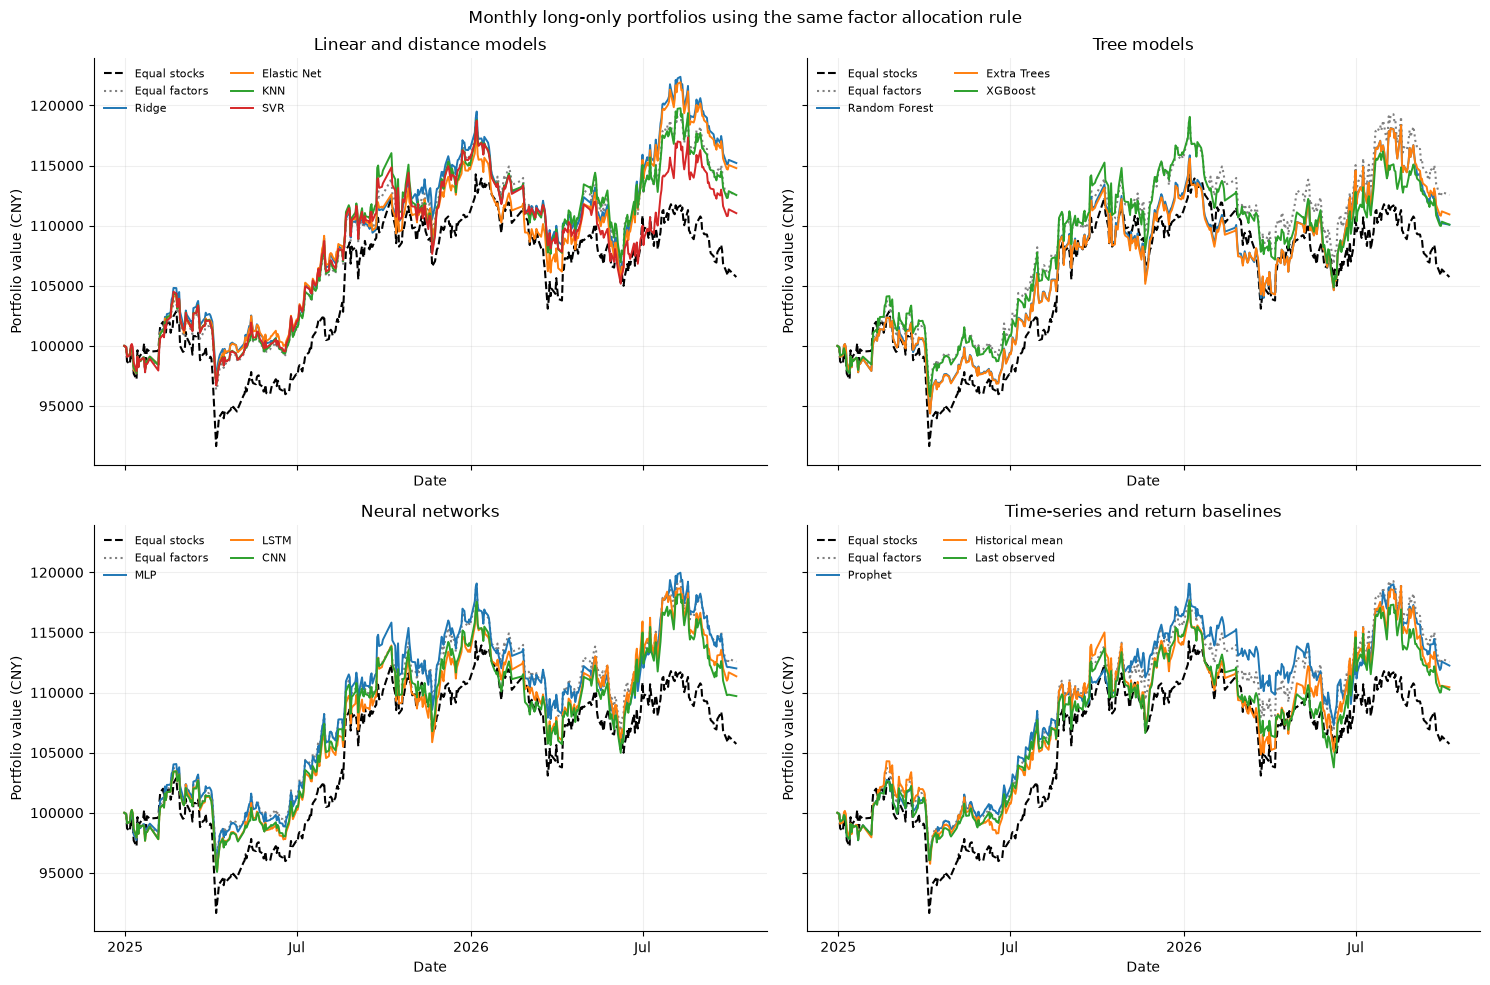

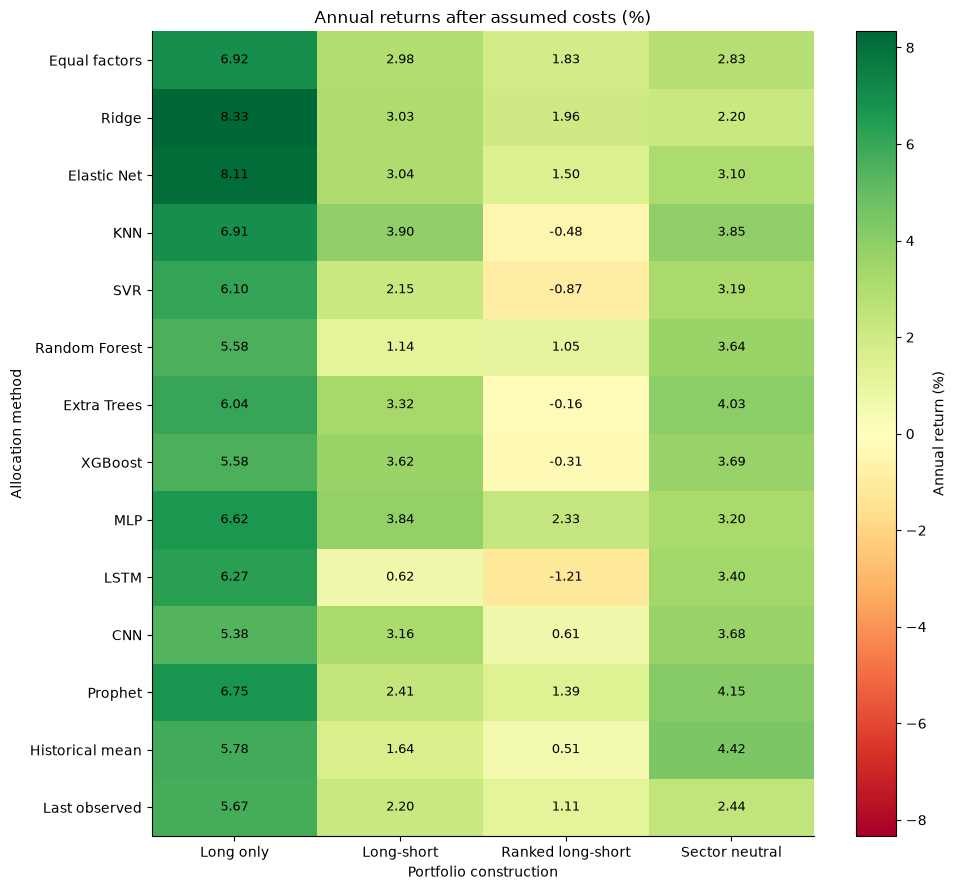

In [15]:
groups = {
    'Linear and distance models': ['Ridge', 'Elastic Net', 'KNN', 'SVR'],
    'Tree models': ['Random Forest', 'Extra Trees', 'XGBoost'],
    'Neural networks': ['MLP', 'LSTM', 'CNN'],
    'Time-series and return baselines': ['Prophet', 'Historical mean', 'Last observed']
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
for ax, (title, names) in zip(axes.flat, groups.items()):
    ax.plot(portfolio_values.index, portfolio_values['Monthly equal stocks'], color='black', linestyle='--', label='Equal stocks')
    ax.plot(portfolio_values.index, portfolio_values['Long only | Equal factors'], color='gray', linestyle=':', label='Equal factors')
    for name in names:
        key = f'Long only | {name}'
        if key in portfolio_values:
            ax.plot(portfolio_values.index, portfolio_values[key], label=name, linewidth=1.4)
    ax.set(title=title, xlabel='Date', ylabel='Portfolio value (CNY)')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8, ncol=2)
    locator = AutoDateLocator(minticks=3, maxticks=5)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
fig.suptitle('Monthly long-only portfolios using the same factor allocation rule')
fig.tight_layout()
fig.savefig(RESULTS / 'all_model_portfolios.png', dpi=160)
plt.show()

returns = pd.DataFrame({mode: {name: performance.loc[f'{mode} | {name}', 'Annual return %'] for name in ['Equal factors'] + complete_models[mode]} for mode in MODES}).reindex(['Equal factors'] + MODEL_NAMES)
fig, ax = plt.subplots(figsize=(10, 9))
limit = np.nanmax(np.abs(returns.to_numpy()))
picture = ax.imshow(returns, cmap='RdYlGn', vmin=-limit, vmax=limit, aspect='auto')
ax.set_xticks(range(len(MODES)), MODES)
ax.set_yticks(range(len(returns)), returns.index)
for row in range(len(returns)):
    for column in range(len(MODES)):
        value = returns.iloc[row, column]
        if np.isfinite(value):
            ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=9)
ax.set(title='Annual returns after assumed costs (%)', xlabel='Portfolio construction', ylabel='Allocation method')
fig.colorbar(picture, ax=ax, label='Annual return (%)')
fig.tight_layout()
fig.savefig(RESULTS / 'all_model_returns.png', dpi=160)
plt.show()

In [16]:
overlap_rows = []
for signal in test_signals:
    longs = buckets[('Long only', signal)].gt(0)
    for left, right in [('Value', 'Profitability'), ('Value', 'Momentum'), ('Profitability', 'Momentum')]:
        shared = (longs[left] & longs[right]).sum()
        overlap_rows.append({'signal': signal, 'Pair': f'{left} / {right}', 'Shared stocks': shared, 'Overlap %': shared / 5 * 100})
overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(RESULTS / 'overlap.csv', index=False)
display(overlap.groupby('Pair')[['Shared stocks', 'Overlap %']].mean().round(2))

exposure_rows = []
sector_rows = []
for name, frame in weights.items():
    for signal, target in frame.iterrows():
        gross = target.abs().sum()
        sector_net = target.groupby(SECTORS).sum()
        exposure_rows.append({
            'strategy': name, 'signal': signal,
            'Gross exposure %': gross * 100,
            'Net exposure %': target.sum() * 100,
            'Largest stock %': target.abs().max() * 100,
            'Largest sector net %': sector_net.abs().max() * 100,
            'Active stocks': target.abs().gt(1e-10).sum(),
            'Cancelled gross %': max(0, 1 - gross) * 100
        })
        sector_rows.extend({'strategy': name, 'signal': signal, 'sector': sector, 'net_weight': value} for sector, value in sector_net.items())
exposures = pd.DataFrame(exposure_rows)
sector_exposures = pd.DataFrame(sector_rows)
exposures.to_csv(RESULTS / 'rebalance_exposure.csv', index=False)
sector_exposures.to_csv(RESULTS / 'sector_exposure.csv', index=False)
summary = exposures.groupby('strategy', sort=False).agg({
    'Gross exposure %': 'mean', 'Net exposure %': 'mean',
    'Largest stock %': 'max', 'Largest sector net %': 'max',
    'Active stocks': 'mean', 'Cancelled gross %': 'mean'
})
summary.columns = ['Average gross %', 'Average net %', 'Maximum stock %', 'Maximum sector net %', 'Average holdings', 'Average cancelled gross %']
summary.to_csv(RESULTS / 'exposure_summary.csv')
display(summary.round(2))

,Shared stocks,Overlap %
Pair,,
Profitability / Momentum,2.620,52.380
Value / Momentum,1.520,30.480
Value / Profitability,1.860,37.140


,Average gross %,Average net %,Maximum stock %,Maximum sector net %,Average holdings,Average cancelled gross %
strategy,,,,,,
Four-week equal factors,100.000,100.000,20.000,40.000,10.040,0.000
Monthly equal stocks,100.000,100.000,5.000,35.000,20.000,0.000
Long only | Equal factors,100.000,100.000,20.000,40.000,10.050,0.000
Long only | Ridge,100.000,100.000,20.000,42.000,10.050,0.000
Long only | Elastic Net,100.000,100.000,20.000,42.000,10.050,0.000
Long only | KNN,100.000,100.000,20.000,44.000,10.050,0.000
Long only | SVR,100.000,100.000,20.000,48.000,10.050,0.000
Long only | Random Forest,100.000,100.000,20.000,52.000,10.050,0.000
Long only | Extra Trees,100.000,100.000,20.000,52.000,10.050,0.000


The overlap table shows how many stocks the top-five factor portfolios share. The exposure table shows what we actually hold after combining the three factors. We measure the largest stock and sector positions at rebalance. Even when a sector starts with balanced long and short positions, price changes can move it away from that balance before the next rebalance.

The sector chart shows the average size of each sector's net position, using absolute values. It compares the ranked long-short portfolio before and after sector adjustment. A zero bar means that the sector's long and short positions balance at the rebalance dates.

Profitability and Momentum shared the most stocks: 2.62 out of five on average. Value and Profitability shared 1.86, while Value and Momentum shared 1.52. So our three factors often picked some of the same companies.

For Random Forest, average absolute net Financials exposure was 14.71% in the ranked long-short portfolio. After sector adjustment, every sector had zero net exposure at rebalance. The drawdown chart also shows a difference. Random Forest's long-only portfolio had a biggest drop of 10.26%, compared with 4.04% for its sector-neutral portfolio. The exposure table helps us read these figures, since the two portfolios held different amounts and types of positions.

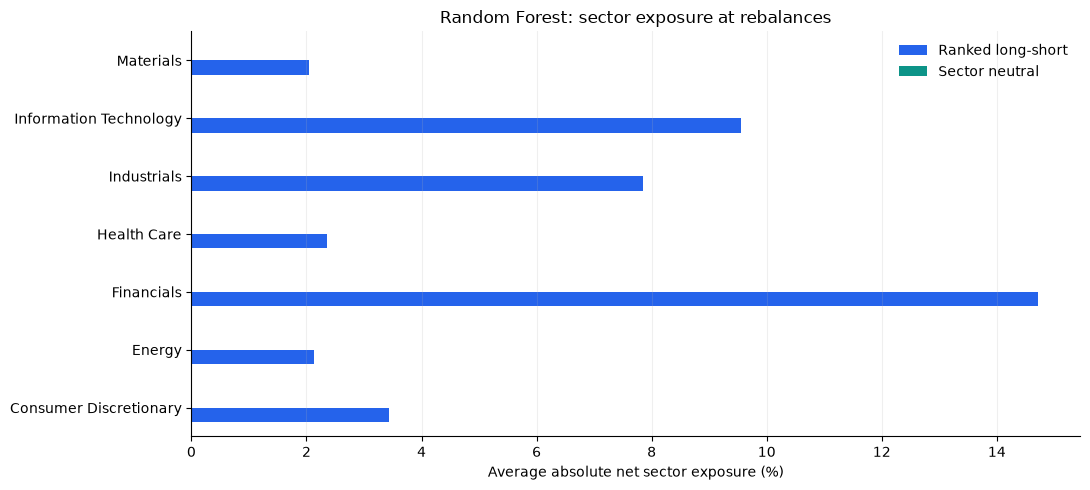

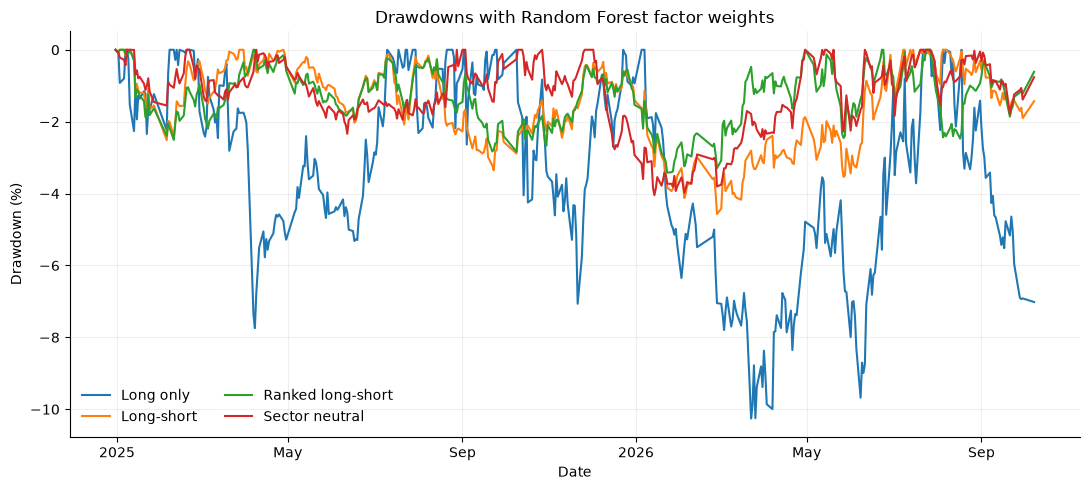

In [17]:
sector_names = [f'{mode} | Random Forest' for mode in ['Ranked long-short', 'Sector neutral'] if f'{mode} | Random Forest' in portfolio_values]
if len(sector_names) == 2:
    sector_chart = sector_exposures.loc[sector_exposures.strategy.isin(sector_names)].copy()
    sector_chart['Absolute net exposure %'] = sector_chart.net_weight.abs() * 100
    sector_chart = sector_chart.groupby(['sector', 'strategy'])['Absolute net exposure %'].mean().unstack().reindex(columns=sector_names)
    sector_chart.columns = ['Ranked long-short', 'Sector neutral']
    ax = sector_chart.plot.barh(figsize=(11, 5), color=['#2563eb', '#0d9488'])
    ax.set(title='Random Forest: sector exposure at rebalances', xlabel='Average absolute net sector exposure (%)', ylabel='')
    ax.grid(axis='x', alpha=0.2)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(RESULTS / 'sector_exposure.png', dpi=160)
    plt.show()
else:
    print('The Random Forest sector chart needs completed forecasts for both constructions.')

drawdown_names = [mode for mode in MODES if f'{mode} | Random Forest' in portfolio_values]
if drawdown_names:
    fig, ax = plt.subplots(figsize=(11, 5))
    for mode in drawdown_names:
        nav = portfolio_values[f'{mode} | Random Forest']
        ax.plot(nav.index, (nav / nav.cummax() - 1) * 100, label=mode)
    ax.set(title='Drawdowns with Random Forest factor weights', xlabel='Date', ylabel='Drawdown (%)')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=2)
    locator = AutoDateLocator(minticks=5, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
    fig.tight_layout()
    fig.savefig(RESULTS / 'drawdowns.png', dpi=160)
    plt.show()

We call a forecast Up when the predicted return is positive and Down otherwise. Accuracy tells us how often the direction was right. Balanced accuracy gives equal importance to rising and falling outcomes. Down recall tells us how many of the actual falls the model spotted. We also show how often a model predicted Up and how far its return forecasts were from the actual returns, in percentage points. Always Up is our basic direction comparison.

We check these predictions against factor returns before trading and borrowing costs. The factors can hold the same stocks, so their forecasts are related. The model rankings describe this test period. They are not a separate test of a model picked after looking at these results.

For the long-only factors, LSTM got 38 of 63 directions right, or 60.32%. CNN reached 57.14%, and Prophet reached 53.97%. Always Up got 52.38% right. LSTM's balanced accuracy was 58.64%. It spotted seven of the thirty falling outcomes and predicted Up in 85.71% of cases.

For the sector-neutral factors, Prophet had the highest direction accuracy at 66.67%, followed by Extra Trees at 63.49%. CNN and Prophet tied at 53.97% in the top/bottom long-short test. The results changed with the way we built the factor portfolios, so we show accuracy for each version separately.

In [18]:
accuracy_rows = []
for mode in MODES:
    for name in complete_models[mode] + ['Always Up']:
        reference = 'Historical mean' if name == 'Always Up' else name
        group = forecasts.loc[(forecasts['mode'] == mode) & (forecasts.model == reference)]
        actual_up = group.actual.to_numpy() > 0
        predicted_up = np.ones(len(group), dtype=bool) if name == 'Always Up' else group.prediction.to_numpy() > 0
        up_recall = predicted_up[actual_up].mean() if actual_up.any() else np.nan
        down_recall = (~predicted_up[~actual_up]).mean() if (~actual_up).any() else np.nan
        accuracy_rows.append({'Construction': mode, 'Forecast': name, 'Accuracy %': 100 * (actual_up == predicted_up).mean(), 'Balanced accuracy %': 50 * (up_recall + down_recall), 'Down recall %': 100 * down_recall, 'Predicted Up %': 100 * predicted_up.mean(), 'MAE percentage points': np.nan if name == 'Always Up' else 100 * (group.prediction - group.actual).abs().mean(), 'Forecasts': len(group)})
accuracy = pd.DataFrame(accuracy_rows).set_index(['Construction', 'Forecast'])
accuracy.to_csv(RESULTS / 'forecast_accuracy.csv')
for mode in MODES:
    print(mode)
    display(accuracy.loc[mode].round(2))

Long only


,Accuracy %,Balanced accuracy %,Down recall %,Predicted Up %,MAE percentage points,Forecasts
Forecast,,,,,,
Ridge,47.620,46.820,30.000,66.670,4.200,63
Elastic Net,42.860,41.970,23.330,68.250,5.000,63
KNN,49.210,47.120,3.330,93.650,3.450,63
SVR,53.970,52.420,20.000,82.540,3.250,63
Random Forest,50.790,48.640,3.330,95.240,3.350,63
Extra Trees,49.210,47.120,3.330,93.650,3.340,63
XGBoost,47.620,46.210,16.670,79.370,3.510,63
MLP,47.620,46.670,26.670,69.840,4.430,63
LSTM,60.320,58.640,23.330,85.710,3.330,63


Long-short


,Accuracy %,Balanced accuracy %,Down recall %,Predicted Up %,MAE percentage points,Forecasts
Forecast,,,,,,
Ridge,42.860,42.840,43.750,49.210,2.990,63
Elastic Net,46.030,45.970,50.000,46.030,3.250,63
KNN,50.790,50.500,68.750,31.750,2.120,63
SVR,47.620,47.530,53.120,44.440,2.310,63
Random Forest,42.860,42.590,59.380,33.330,2.200,63
Extra Trees,49.210,48.790,75.000,23.810,2.120,63
XGBoost,52.380,52.170,65.620,36.510,2.250,63
MLP,47.620,47.530,53.120,44.440,2.780,63
LSTM,41.270,41.080,53.120,38.100,2.250,63


Ranked long-short


,Accuracy %,Balanced accuracy %,Down recall %,Predicted Up %,MAE percentage points,Forecasts
Forecast,,,,,,
Ridge,42.860,42.880,43.330,49.210,2.400,63
Elastic Net,38.100,38.180,40.000,47.620,2.540,63
KNN,47.620,48.030,56.670,41.270,1.760,63
SVR,41.270,40.760,30.000,60.320,1.850,63
Random Forest,41.270,41.670,50.000,41.270,1.810,63
Extra Trees,44.440,45.450,66.670,28.570,1.780,63
XGBoost,33.330,33.330,33.330,49.210,2.000,63
MLP,53.970,54.550,66.670,38.100,2.080,63
LSTM,44.440,45.450,66.670,28.570,1.800,63


Sector neutral


,Accuracy %,Balanced accuracy %,Down recall %,Predicted Up %,MAE percentage points,Forecasts
Forecast,,,,,,
Ridge,52.380,51.970,43.330,58.730,1.900,63
Elastic Net,47.620,47.120,36.670,60.320,2.140,63
KNN,53.970,54.240,60.000,44.440,1.430,63
SVR,52.380,52.120,46.670,55.560,1.410,63
Random Forest,57.140,58.030,76.670,31.750,1.380,63
Extra Trees,63.490,63.640,66.670,47.620,1.340,63
XGBoost,60.320,60.610,66.670,44.440,1.400,63
MLP,57.140,56.670,46.670,60.320,1.700,63
LSTM,57.140,57.580,66.670,41.270,1.410,63


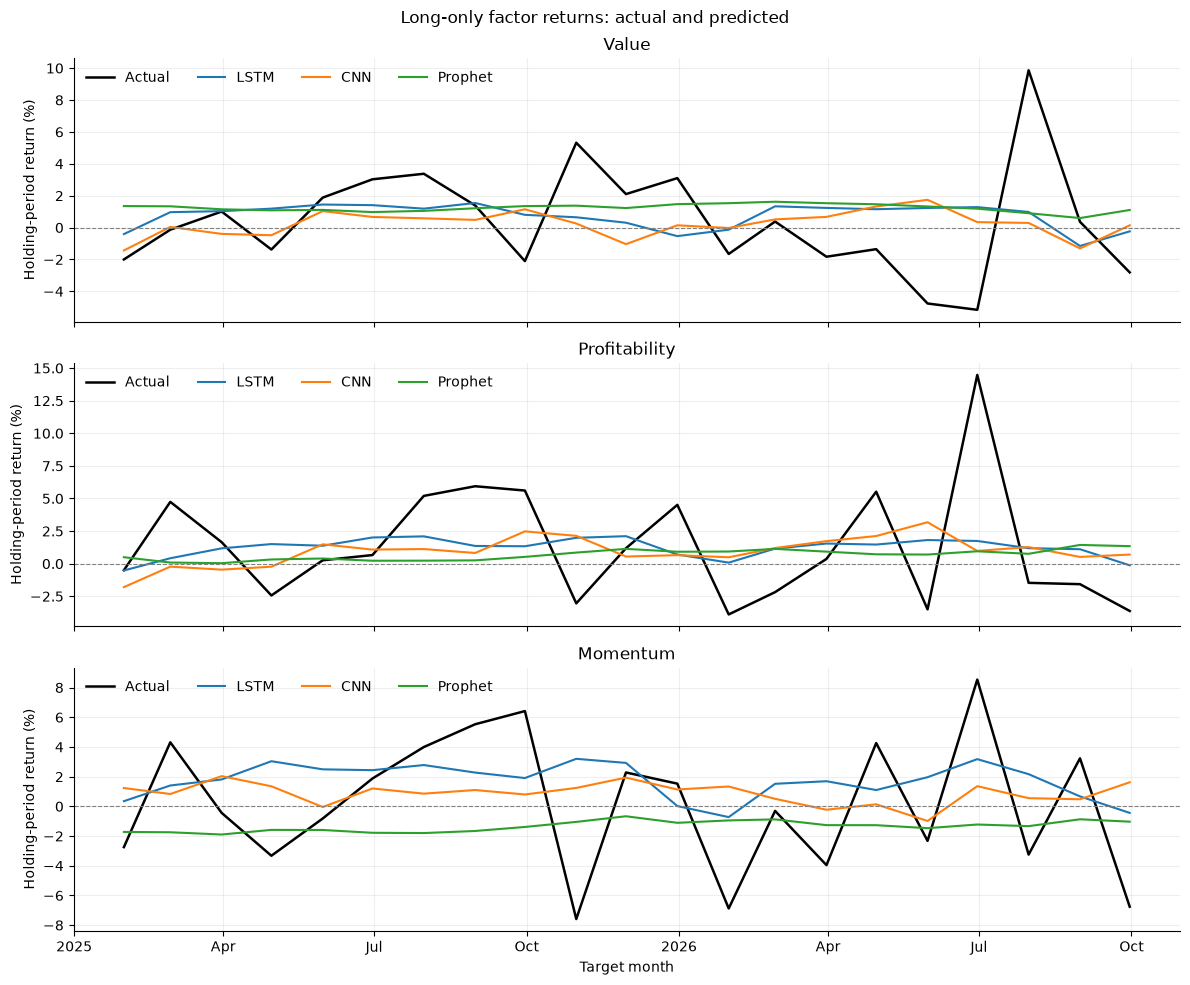

Last completed test: signal 2026-08-31, holding period 2026-09-01 to 2026-10-08.


factor,Value,Profitability,Momentum
model,,,
Ridge,4.55% (Up),0.29% (Up),1.50% (Up)
Elastic Net,6.74% (Up),0.50% (Up),3.04% (Up)
KNN,0.73% (Up),0.64% (Up),-0.46% (Down)
SVR,1.37% (Up),0.12% (Up),0.01% (Up)
Random Forest,0.30% (Up),0.26% (Up),0.64% (Up)
Extra Trees,0.37% (Up),0.06% (Up),0.14% (Up)
XGBoost,0.82% (Up),-1.17% (Down),0.43% (Up)
MLP,0.32% (Up),-0.64% (Down),0.58% (Up)
LSTM,-0.24% (Down),-0.12% (Down),-0.44% (Down)


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, factor in zip(axes, FACTORS):
    actual = forecasts.loc[(forecasts['mode'] == 'Long only') & (forecasts.factor == factor) & (forecasts.model == 'Historical mean')].set_index('signal').actual
    target_months = actual.index + pd.offsets.MonthEnd(1)
    ax.plot(target_months, actual * 100, color='black', label='Actual', linewidth=1.8)
    for name in ['LSTM', 'CNN', 'Prophet']:
        prediction = forecasts.loc[(forecasts['mode'] == 'Long only') & (forecasts.factor == factor) & (forecasts.model == name)].set_index('signal').prediction
        if len(prediction) == len(actual):
            ax.plot(target_months, prediction.reindex(actual.index) * 100, label=name)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set(title=factor, ylabel='Holding-period return (%)')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=4)
locator = AutoDateLocator(minticks=4, maxticks=8)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(ConciseDateFormatter(locator))
axes[-1].set_xlabel('Target month')
fig.suptitle('Long-only factor returns: actual and predicted')
fig.tight_layout()
fig.savefig(RESULTS / 'deep_factor_predictions.png', dpi=160)
plt.show()

last_signal = test_signals[-1]
latest = forecasts.loc[(forecasts['mode'] == 'Long only') & (forecasts.signal == last_signal)].copy()
latest['Prediction'] = latest['prediction'].map(lambda value: f'{value:.2%}') + ' (' + latest.trend + ')'
latest.to_csv(RESULTS / 'last_test_predictions.csv', index=False)
print(f'Last completed test: signal {last_signal.date()}, holding period {latest.entry.iloc[0].date()} to {latest.exit.iloc[0].date()}.')
display(latest.pivot(index='model', columns='factor', values='Prediction').reindex(index=MODEL_NAMES, columns=FACTORS))

The last prediction table is from the final completed historical test. It is not a forecast for today. Between 1 September and 8 October 2026, Value returned -2.81%, Profitability -3.63% and Momentum -6.76% in the long-only portfolios. LSTM predicted a fall in all three, so it got each direction right in this period. It predicted falls of 0.24%, 0.12% and 0.44%, in the same order. The actual falls were larger.

We also checked how borrowing costs changed the results for each model. With equal factor weights in the top/bottom long-short portfolio, annualised return was 4.10% with no borrowing charge. It fell to 2.98% with the 3% yearly charge used in our main test, and to 1.87% with a 6% charge. The 3% case paid CNY 1,928.81 in borrowing costs over the full test period. The table below shows the same comparison for every model.

In [20]:
sensitivity_rows = []
for mode in MODES[1:]:
    for model_name in ['Equal factors'] + complete_models[mode]:
        name = f'{mode} | {model_name}'
        for rate in [0.0, 0.03, 0.06]:
            if rate == BORROW_RATE:
                result = performance.loc[name]
            else:
                nav, log, _ = backtest(prices, monthly_schedule, weights[name], INITIAL_VALUE, TRADING_COST, rate)
                result = performance_row(nav, log)
            sensitivity_rows.append({'Construction': mode, 'Model': model_name, 'Annual borrowing assumption %': rate * 100, 'Annual return %': result['Annual return %'], 'Borrowing costs CNY': result['Borrowing costs CNY']})
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(RESULTS / 'borrowing_sensitivity.csv', index=False)
for mode in MODES[1:]:
    print(mode)
    display(sensitivity.loc[sensitivity.Construction == mode].pivot(index='Model', columns='Annual borrowing assumption %', values='Annual return %').reindex(['Equal factors'] + complete_models[mode]).round(2))

Long-short


Annual borrowing assumption %,0.000,3.000,6.000
Model,,,
Equal factors,4.100,2.980,1.870
Ridge,4.180,3.030,1.890
Elastic Net,4.190,3.040,1.900
KNN,5.130,3.900,2.690
SVR,3.320,2.150,0.990
Random Forest,2.310,1.140,-0.010
Extra Trees,4.550,3.320,2.090
XGBoost,4.790,3.620,2.450
MLP,5.000,3.840,2.690


Ranked long-short


Annual borrowing assumption %,0.000,3.000,6.000
Model,,,
Equal factors,2.830,1.830,0.840
Ridge,2.990,1.960,0.950
Elastic Net,2.520,1.500,0.500
KNN,0.560,-0.480,-1.510
SVR,0.150,-0.870,-1.870
Random Forest,2.100,1.050,0.000
Extra Trees,0.880,-0.160,-1.200
XGBoost,0.710,-0.310,-1.320
MLP,3.370,2.330,1.300


Sector neutral


Annual borrowing assumption %,0.000,3.000,6.000
Model,,,
Equal factors,3.970,2.830,1.710
Ridge,3.350,2.200,1.060
Elastic Net,4.260,3.100,1.940
KNN,5.060,3.850,2.660
SVR,4.390,3.190,2.010
Random Forest,4.880,3.640,2.410
Extra Trees,5.250,4.030,2.810
XGBoost,4.910,3.690,2.490
MLP,4.390,3.200,2.020


We tested all eleven models on the same 20 A-share companies over 21 monthly holding periods. Ridge gave us the highest long-only annualised return at 8.33%, with Elastic Net close behind at 8.11%. Equal factor weights returned 6.92%, and equal stock weights returned 3.20%. LSTM returned 6.27%, CNN 5.38% and Prophet 6.75%, after trading costs. LSTM got the most directions right in this long-only comparison: 60.32% of the 63 forecasts. Its biggest portfolio drop was 9.62%, compared with 11.42% for Ridge. With sector-neutral portfolios, Prophet returned 4.15% and Extra Trees 4.03%, while the historical-average rule returned 4.42%. So we found two different things: LSTM was better at getting direction right in the long-only test, but Ridge made more money. Changing how we built the portfolios also changed which model led the comparison.